## E-Commerce Sales Analysis Dashboard

**Objective**

Analyze an e-commerce sales dataset and create a dashboard using Matplotlib to answer business questions.

Dataset Columns:

- order_id
- order_date
- customer_id
- product_category
- region
- quantity
- unit_price
- discount
- payment_method
- delivery_days
- customer_rating
- revenue


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ecommerce_sales.csv")

df["order_date"] = pd.to_datetime(df["order_date"])
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month_name()
df["month"] = pd.Categorical(
    df["month"],
    categories=[
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December",
    ],
)
# pd.categorical helps ensure the months are plotted in the correct chronological order


C:\Users\User\AppData\Local\Temp\ipykernel_25080\1456622075.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby("month")["revenue"].sum()


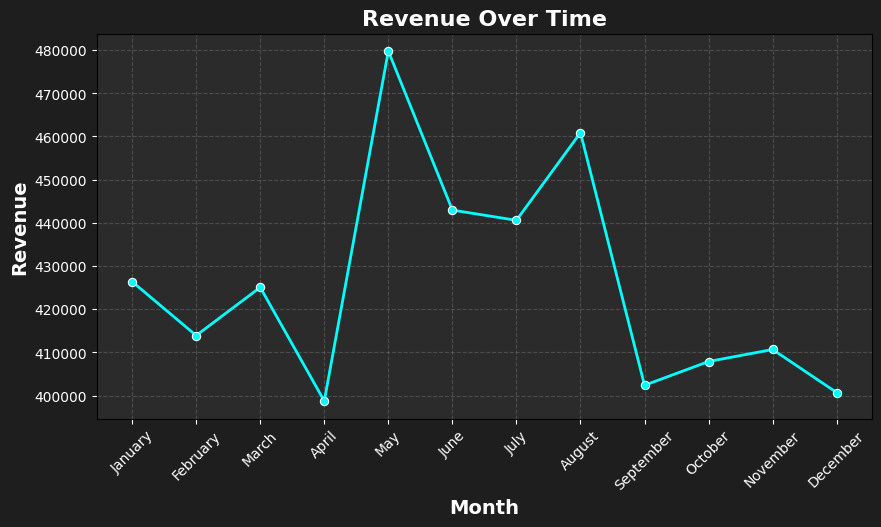

In [2]:
# 1. Line Plot for Revenue Over Months
# Question: How has the revenue changed over the months?

monthly_sales = df.groupby("month")["revenue"].sum()
# monthly_sales.index means names of the months, which will be plotted on the x-axis of the graph.
# monthly_sales.values means respective revenue values for each month, which will be plotted on the y-axis of the graph.

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

sns.lineplot(
    x=monthly_sales.index, y=monthly_sales.values, marker="o", color="cyan", linewidth=2, ax=ax
)

plt.title("Revenue Over Time", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Month", fontsize=14, fontweight="bold", color="white")
plt.ylabel("Revenue", fontsize=14, fontweight="bold", color="white")
plt.xticks(rotation=45)
plt.tick_params(axis="both", colors="white")
plt.grid(linestyle="--", alpha=0.25)
plt.savefig("outputs/Revenue_Over_Months.png", dpi=300, bbox_inches="tight")
plt.show()


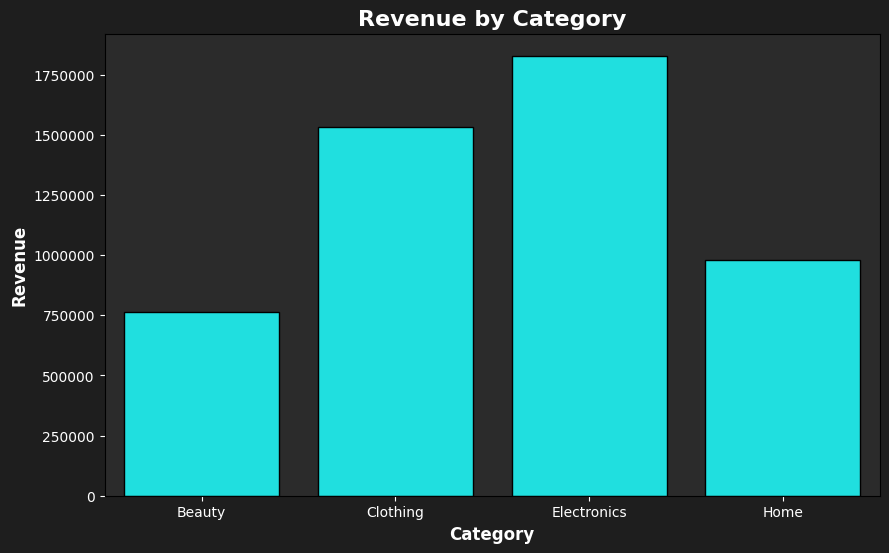

In [3]:
# 2. Bar Plot for Revenue by Product Category
# Question: What is the total revenue generated by each product category?
cat_sales = df.groupby("product_category")["revenue"].sum()

fig = plt.figure(figsize=(10, 6))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

sns.barplot(x=cat_sales.index, y=cat_sales.values, color="cyan", edgecolor="black", ax=ax)

plt.title("Revenue by Category", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Category", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Revenue", fontsize=12, fontweight="bold", color="white")
plt.ticklabel_format(style="plain", axis="y")  # to remove 1e6 format on y axis
plt.tick_params(axis="both", colors="white")
plt.savefig("outputs/Revenue_by_Product_Category.png", dpi=300, bbox_inches="tight")
plt.show()


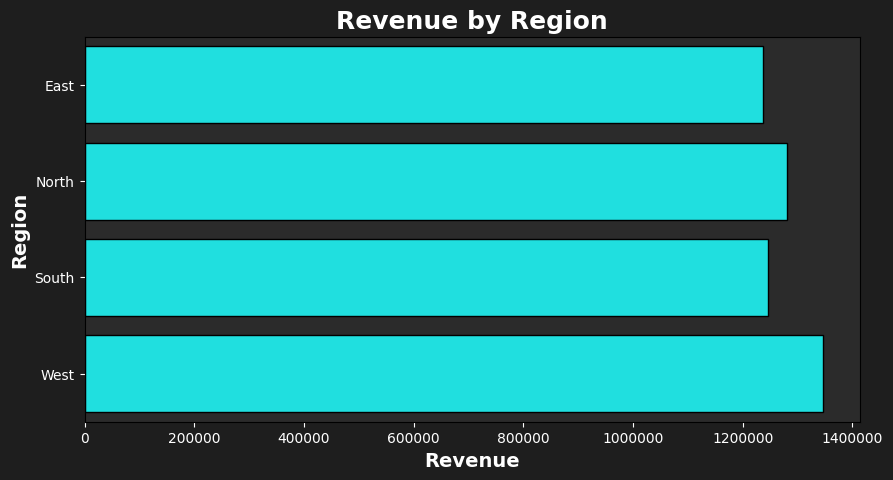

In [4]:
# 3. Horizontal Bar Plot for Revenue by Region
# Question: Which region has generated the highest revenue?

region_sales = df.groupby("region")["revenue"].sum()

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

sns.barplot(x=region_sales.values, y=region_sales.index, color="cyan", edgecolor="black", orient="h", ax=ax)

plt.title("Revenue by Region", fontsize=18, fontweight="bold", color="white")
plt.xlabel("Revenue", fontsize=14, fontweight="bold", color="white")
plt.ylabel("Region", fontsize=14, fontweight="bold", color="white")
# plt.xticks(rotation=45)
plt.ticklabel_format(style="plain", axis="x")  # to remove 1e6 format on x axis
plt.tick_params(axis="both", colors="white")
plt.savefig("outputs/Revenue_by_Region.png", dpi=300, bbox_inches="tight")
plt.show()


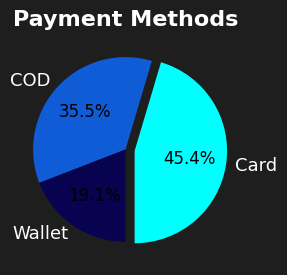

In [5]:
# 4. Pie Chart: payment methods
# Question: What is the distribution of payment methods used by customers?
# Note: seaborn has no pie-chart function, so this one stays on matplotlib's ax.pie (same formatting as before).
payments = df["payment_method"].value_counts()

fig = plt.figure(figsize=(20, 3))  # Create a new figure
fig.patch.set_facecolor(
    "#1e1e1e"
)  # Set the background color of the figure to a dark shade
ax = plt.gca()  # Get the current axes of the figure
ax.set_facecolor(
    "#2b2b2b"
)  # Set the background color of the axes to a slightly lighter dark shade

colors = ["cyan", "#1060E2F1", "#080350"]

wedges, texts, autotexts = (
    ax.pie(  # Create a pie chart , wedges are the slices of the pie, texts are the labels, and autotexts are the percentage values
        payments,
        labels=payments.index,
        autopct="%1.1f%%",
        colors=colors,
        startangle=270,
        explode=(0.1, 0, 0),
    )
)
# make legend white
for text in texts:
    text.set_color("white")
    text.set_fontsize(13)

# Make percentages black
for autotext in autotexts:
    autotext.set_color("black")
    autotext.set_fontsize(12)

plt.title("Payment Methods", color="white", fontsize=16, fontweight="bold")

plt.savefig("outputs/Payment_Methods.png", dpi=300, bbox_inches="tight")
plt.show()


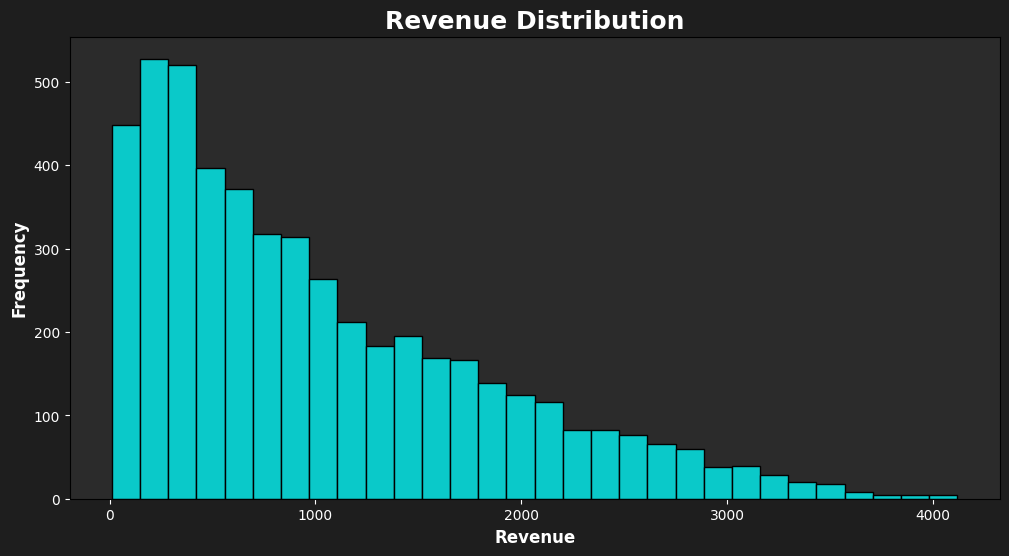

In [6]:
# 5. Histogram: Revenue Distribution
# Question: What is the distribution of revenue across all orders?

fig = plt.figure(figsize=(12, 6))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

sns.histplot(df["revenue"], bins=30, color="cyan", edgecolor="black", ax=ax)
plt.tick_params(axis="both", colors="white")
plt.title("Revenue Distribution", fontsize=18, fontweight="bold", color="white")
plt.xlabel("Revenue", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Frequency", fontsize=12, fontweight="bold", color="white")

plt.savefig("outputs/Revenue_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\categorical.py:700: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  artists = ax.bxp(**boxplot_kws)


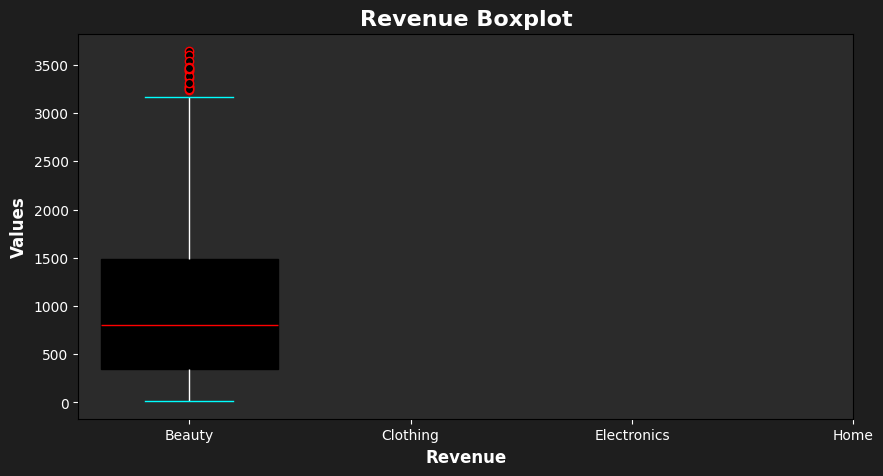

In [7]:
# 6. Box Plot : to detect outliers
# Question: Are there any outliers in the revenue data?

groups = []
for c in df["product_category"].unique():
    groups.append(
        df[df["product_category"] == c]["revenue"]
    )  # grouping revenue data by product category to create a list of revenue values for each category

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

sns.boxplot(
    data=groups,
    ax=ax,
    medianprops=dict(color="red"),
    boxprops=dict(facecolor="cyan", color="black"),
    whiskerprops=dict(color="white"),
    capprops=dict(color="cyan"),
    flierprops=dict(markerfacecolor="black", markeredgecolor="red"),
)
ax.set_xticks(range(len(df["product_category"].unique())))
ax.set_xticklabels(df["product_category"].unique())

# medianprops=dict(color="red") sets the color of the median line to red,
# boxprops=dict(facecolor="cyan", color="black") sets the color of the box to cyan,
# whiskerprops=dict(color="white") sets the color of the whiskers to white,
# capprops=dict(color="cyan") sets the color of the caps to cyan,
# flierprops=dict(markerfacecolor="black", markeredgecolor="red") sets the color of the outliers to black with red edges.

plt.tick_params(axis="both", colors="white")
plt.title("Revenue Boxplot", color="white", fontsize=16, fontweight="bold")
plt.xlabel("Revenue", color="white", fontsize=12, fontweight="bold")
plt.ylabel("Values", color="white", fontsize=12, fontweight="bold")

plt.savefig("outputs/Revenue_Boxplot.png", dpi=300, bbox_inches="tight")
plt.show()


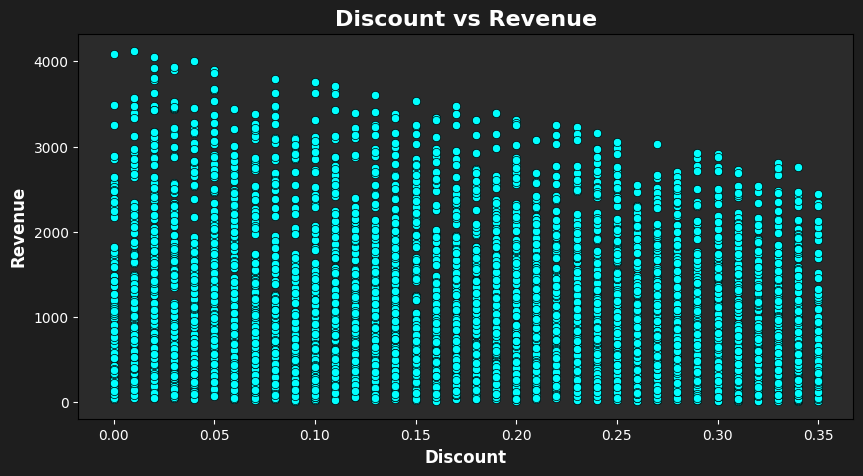

In [8]:
# 7. Scatter Plot: Revenue vs. Quantity
# Question: Is there a relationship between the quantity of products sold and the revenue generated?

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

sns.scatterplot(x=df["discount"], y=df["revenue"], color="cyan", edgecolor="black", ax=ax)

plt.xlabel("Discount", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Revenue", fontsize=12, fontweight="bold", color="white")
plt.title("Discount vs Revenue", fontsize=16, fontweight="bold", color="white")
plt.tick_params(axis="both", colors="white")

plt.savefig("outputs/Discount_Vs_Revenue.png", dpi=300, bbox_inches="tight")
plt.show()
# plot shows a positive correlation between discount and revenue , this means that as the discount increases, the revenue also increases. This could be due to the fact that customers are more likely to purchase products when they are offered at a discount, leading to an increase in revenue.
# positive can be detrmined seeing this plot, as the points are generally trending upwards from left to right.


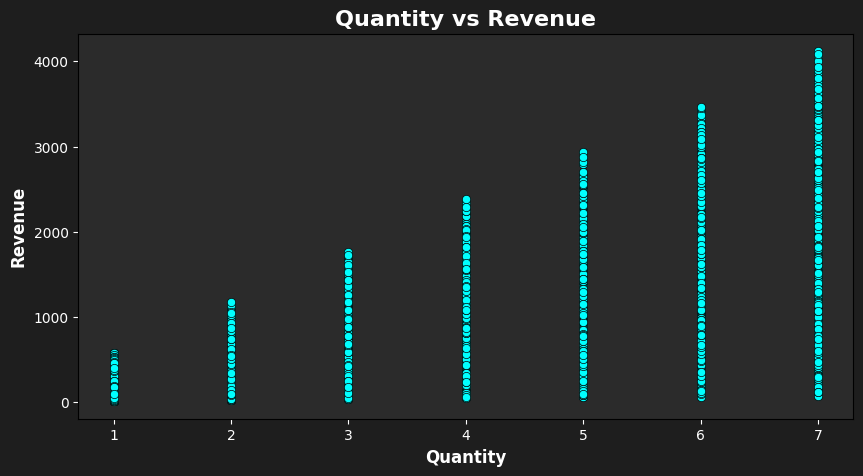

In [9]:
# 8. Scatter Plot: Revenue vs. Quantity
# Question: Is there a relationship between the quantity of products sold and the revenue generated?

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

sns.scatterplot(x=df["quantity"], y=df["revenue"], color="cyan", edgecolor="black", ax=ax)

plt.xlabel("Quantity", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Revenue", fontsize=12, fontweight="bold", color="white")
plt.title("Quantity vs Revenue", fontsize=16, fontweight="bold", color="white")
plt.tick_params(axis="both", colors="white")

plt.savefig("outputs/Quantity_Vs_Revenue.png", dpi=300, bbox_inches="tight")
plt.show()

# As plot shows a positive correlation between quantity and revenue, this means that as the quantity of products sold increases, the revenue also increases. This is expected, as selling more products should lead to higher revenue.


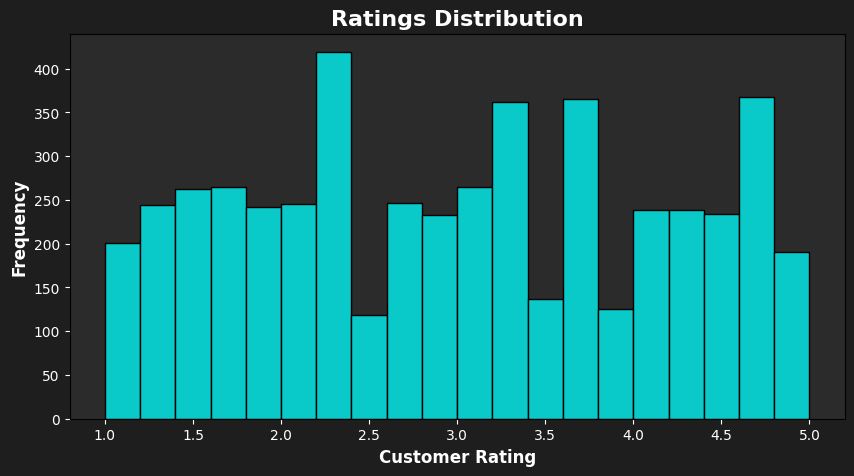

In [10]:
# 9. Histogram: Ratings Distribution
# Question: What is the distribution of customer ratings?

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

sns.histplot(df["customer_rating"], bins=20, color="cyan", edgecolor="black", ax=ax)

plt.title("Ratings Distribution", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Customer Rating", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Frequency", fontsize=12, fontweight="bold", color="white")
plt.tick_params(axis="both", colors="white")

plt.savefig("outputs/Ratings_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()


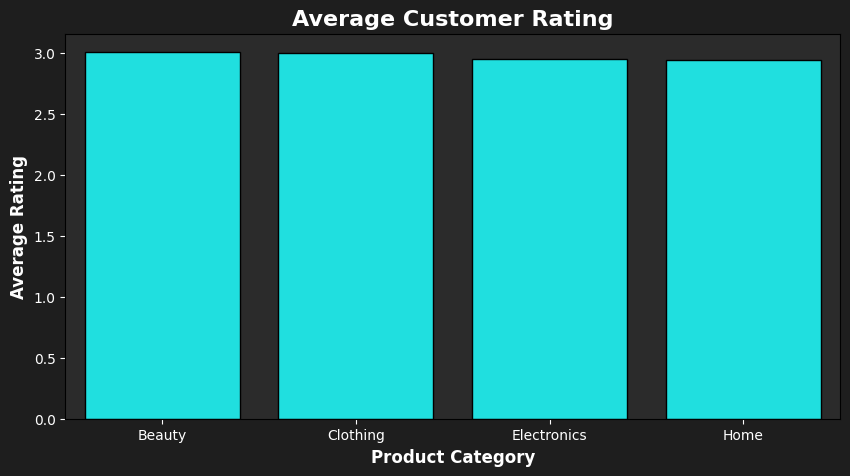

In [11]:
# 10. Bar Plot: Average Customer Rating by Product Category
# Question: What is the average customer rating for each product category?
rating = df.groupby("product_category")["customer_rating"].mean()

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

sns.barplot(x=rating.index, y=rating.values, color="cyan", edgecolor="black", ax=ax)

plt.title("Average Customer Rating", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Product Category", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Average Rating", fontsize=12, fontweight="bold", color="white")
plt.tick_params(axis="both", colors="white")

plt.savefig("outputs/Average_Customer_Rating.png", dpi=300, bbox_inches="tight")
plt.show()


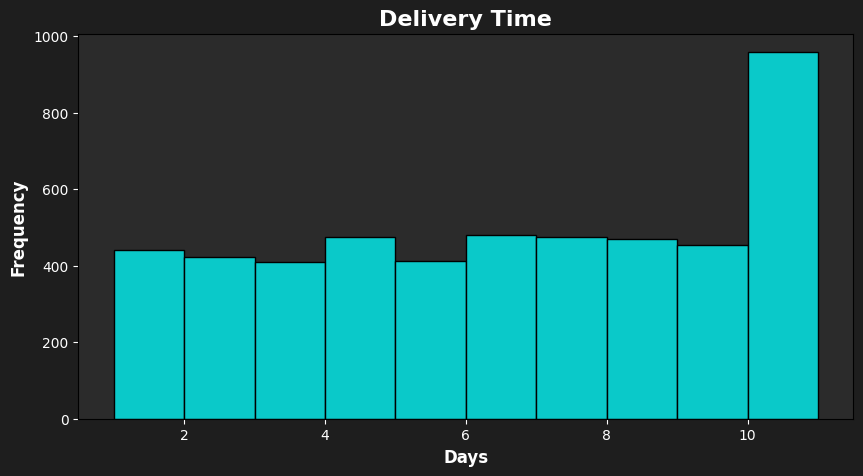

In [12]:
# 11. Histogram: Delivery Time Distribution
# Question: What is the distribution of delivery times for orders?

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

sns.histplot(df["delivery_days"], bins=10, color="cyan", edgecolor="black", ax=ax)

plt.title("Delivery Time", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Days", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Frequency", fontsize=12, fontweight="bold", color="white")
plt.tick_params(axis="both", colors="white")

plt.savefig("outputs/Delivery_Time_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

# histogram shows delivery times are mostly clustered toward the higher end, with a strong peak around 10-11 days. That means orders generally take a long time to be delivered, and the distribution is not uniform or balanced across the full range.


product_category     Beauty   Clothing  Electronics       Home
region                                                        
East              174909.11  402582.60    411803.35  246749.17
North             186213.32  364659.43    472450.93  258184.77
South             191073.98  348363.14    487055.68  220148.10
West              213664.47  416326.55    458589.26  257001.88


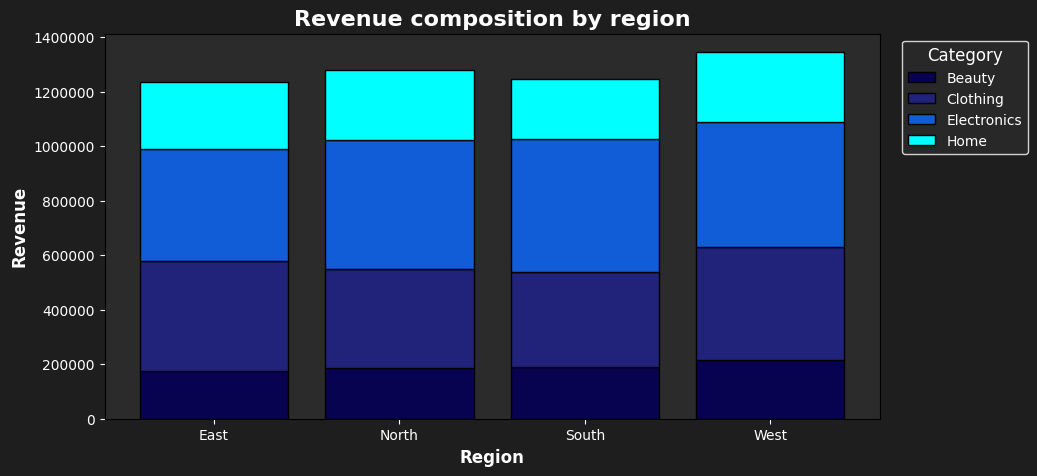

In [13]:
# 12. Stacked Bar Plot: Revenue Composition by Region and Product Category
# Question: How does the revenue composition vary across different regions and product categories?
# Note: seaborn has no built-in stacked-bar chart, so this one stays on matplotlib's plt.bar (same formatting as before).
pivot = df.pivot_table(
    values="revenue", index="region", columns="product_category", aggfunc="sum"
)
# values='revenue' means we want to aggregate the revenue values,
# index='region' means we want to group the data by region,
# columns='product_category' means we want to create separate columns for each product category,
# and aggfunc='sum' means we want to sum the revenue values for each combination of region and product category.
print(pivot)

fig = plt.figure(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

bottom = None  # bottom = none means
colors = ["#080350", "#212279", "#1060E2F1", "cyan"]
i = 0
for col in pivot.columns:
    plt.bar(
        pivot.index,
        pivot[col],
        bottom=bottom,
        label=col,
        edgecolor="black",
        color=colors[i],
    )
    i = i + 1
    if bottom is None:
        bottom = pivot[col]
    else:
        bottom += pivot[col]

plt.title(
    "Revenue composition by region", fontsize=16, fontweight="bold", color="white"
)
plt.xlabel("Region", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Revenue", fontsize=12, fontweight="bold", color="white")
plt.ticklabel_format(style="plain", axis="y")  # to remove 1e6 format on y axis
plt.tick_params(axis="both", colors="white")
legend = plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=10,
    title="Category",
    facecolor="#2b2b2b",
    edgecolor="white",
    title_fontsize=12,
)
plt.setp(legend.get_texts(), color="white")
plt.setp(legend.get_title(), color="white")

plt.savefig("outputs/Revenue_Composition_by_Region.png", dpi=300, bbox_inches="tight")
plt.show()

# plot shows that the revenue composition varies across different regions and product categories. For example, in the North region, the Electroni


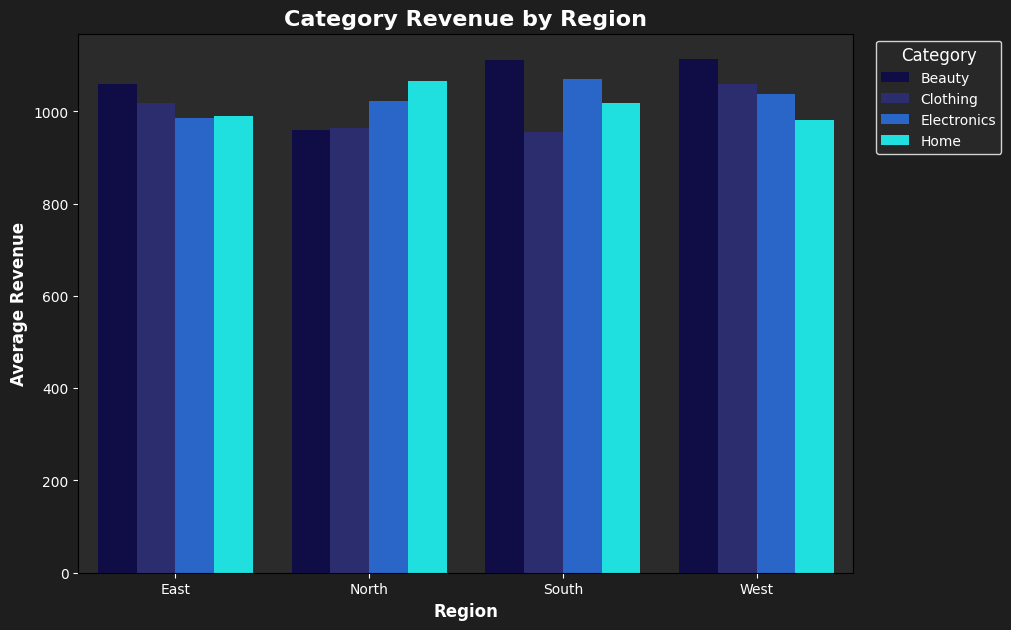

In [14]:
# 13. Dodged Bar Plot: Average Revenue by Region and Product Category
# Question: What is the average revenue generated by each product category in different regions?
pivott = df.pivot_table(
    values="revenue", index="region", columns="product_category", aggfunc="mean"
)
pivott_long = pivott.reset_index().melt(
    id_vars="region", var_name="product_category", value_name="revenue"
)  # sns.barplot needs long-format data to dodge bars by hue

fig = plt.figure(figsize=(10, 7))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

colors = ["#080350", "#212279", "#1060E2F1", "cyan"]
sns.barplot(
    data=pivott_long,
    x="region",
    y="revenue",
    hue="product_category",
    palette=colors,
    ax=ax,
)

plt.title("Category Revenue by Region", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Region", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Average Revenue", fontsize=12, fontweight="bold", color="white")
plt.ticklabel_format(style="plain", axis="y")  # to remove 1e6 format on y axis
plt.tick_params(axis="both", colors="white")
plt.xticks(rotation=0)
legend = plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=10,
    title="Category",
    facecolor="#2b2b2b",
    edgecolor="white",
    title_fontsize=12,
)
plt.setp(legend.get_texts(), color="white")
plt.setp(legend.get_title(), color="white")

plt.savefig(
    "outputs/Average_Revenue_by_Region_and_Category.png", dpi=300, bbox_inches="tight"
)
plt.show()

# plot shows that the average revenue generated by each product category varies across different regions. For example, in the North region, the Electronics category has the highest average revenue, while in the South region, the Clothing category has the highest average revenue. This information can help businesses understand which product categories are performing well in different regions and make informed decisions about marketing and sales strategies.


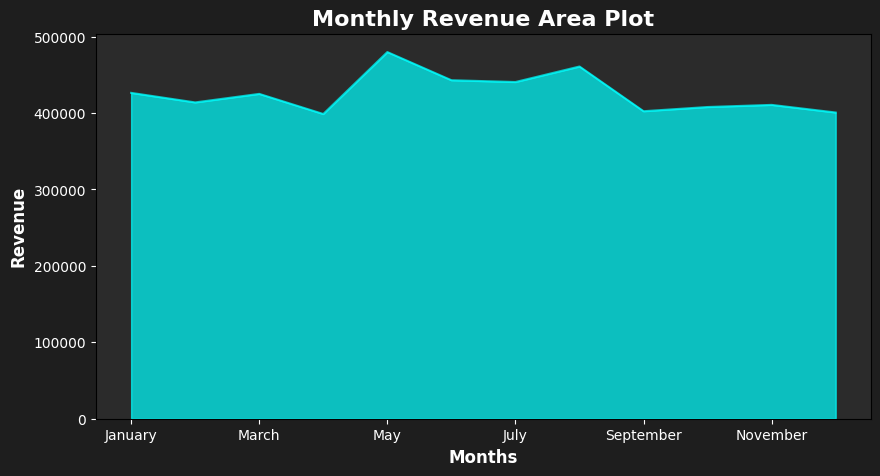

In [15]:
# 14. Area Plot: Monthly Revenue Over Time
# Question: How has the revenue changed over the months?
# Note: seaborn has no area-chart function, so this one stays on pandas'/matplotlib's .plot.area (same formatting as before).
fig = plt.figure(figsize=(10, 8))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

monthly_sales.plot.area(figsize=(10, 5), color="cyan", alpha=0.7)

plt.title("Monthly Revenue Area Plot", fontsize=16, fontweight="bold", color="white")
plt.xlabel("Months", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Revenue", fontsize=12, fontweight="bold", color="white")
plt.tick_params(axis="both", colors="white")

plt.savefig("outputs/Monthly_Revenue_Area_Plot.png", dpi=300, bbox_inches="tight")
plt.show()


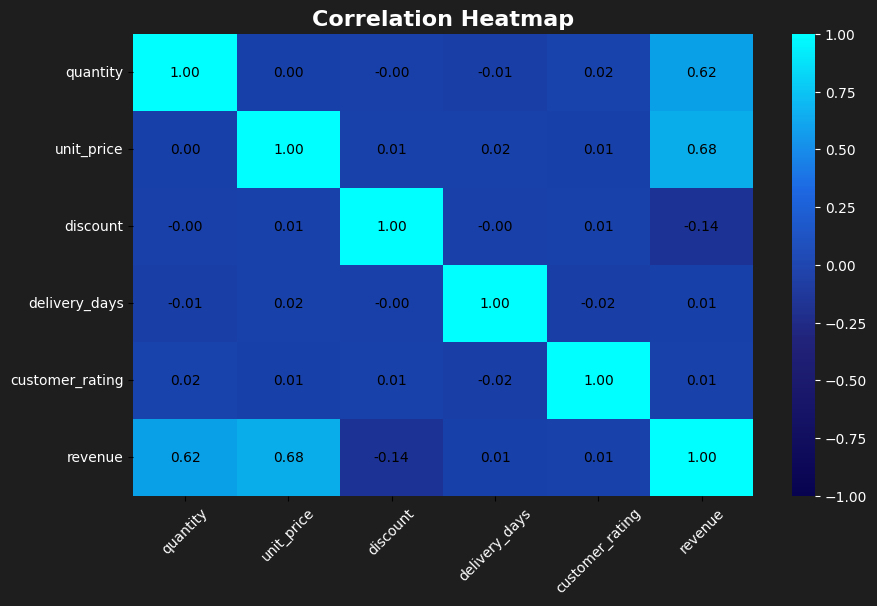

In [16]:
# 15. Correlation Heatmap: Relationships Between Variables
# Question: How are the different variables in the dataset related to each other?

corr = df[
    [
        "quantity",
        "unit_price",
        "discount",
        "delivery_days",
        "customer_rating",
        "revenue",
    ]
].corr()  # corr() calculates the correlation matrix for the specified columns in the DataFrame. The correlation matrix shows the pairwise correlation coefficients between the variables, indicating how strongly they are related to each other.

fig = plt.figure(
    figsize=(10, 6)
)  # figure(figsize=(8, 6)) creates a new figure with a specified size of 8 inches by 6 inches. This is where the heatmap will be plotted.
fig.patch.set_facecolor(
    "#1e1e1e"
)  # sets the background color of the figure to a dark shade, which can help improve the visibility of the heatmap.
ax = (
    plt.gca()
)  # get the current axes of the figure, which is where the heatmap will be plotted.
ax.set_facecolor(
    "#2b2b2b"
)  # sets the background color of the axes to a slightly lighter dark shade, which can help improve the visibility of the heatmap.

from matplotlib.colors import (
    LinearSegmentedColormap,
)  # LinearSegmentedColormap is a class in the matplotlib library that allows you to create custom colormaps for visualizations. A colormap is a range of colors used to represent data values in a plot, and LinearSegmentedColormap allows you to define a colormap by specifying a list of colors and their corresponding positions along the colormap.

custom_cmap = LinearSegmentedColormap.from_list(
    "custom", ["#080350", "#212279", "#1060E2F1", "cyan"]
)

sns.heatmap(
    corr,
    cmap=custom_cmap,
    vmin=-1,
    vmax=1,
    annot=True,  # sns.heatmap draws the correlation values on the cells itself, replacing the manual plt.text loop
    fmt=".2f",
    annot_kws={"color": "black", "fontsize": 10},
    ax=ax,
)

cbar = ax.collections[0].colorbar  # adds a colorbar to the heatmap, which provides a reference for interpreting the colors in the heatmap.
cbar.ax.yaxis.set_tick_params(color="white")
plt.setp(cbar.ax.get_yticklabels(), color="white")

plt.xticks(rotation=45, color="white")
plt.yticks(color="white")
plt.title("Correlation Heatmap", fontsize=16, fontweight="bold", color="white")

plt.savefig("outputs/Correlation_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


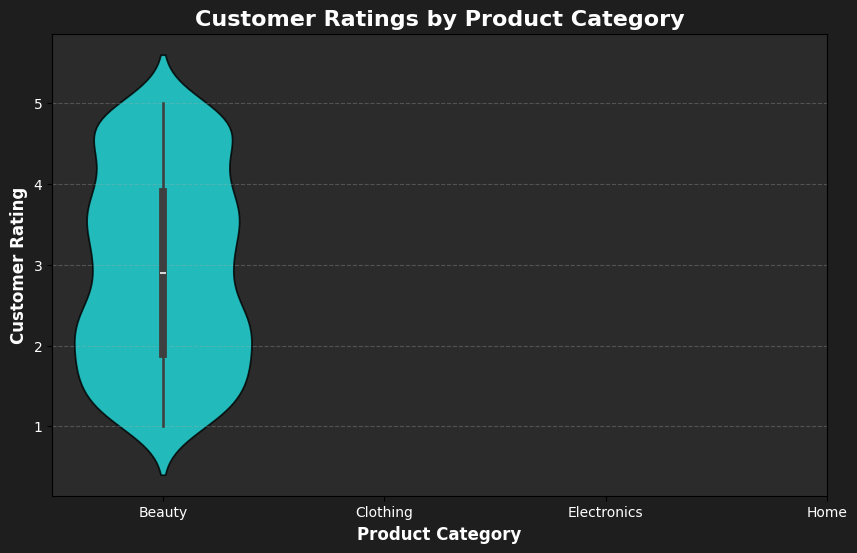

In [17]:
# 16. Violin Plot: Customer Ratings by Product Category
# Question: How do customer ratings vary across different product categories?

data = []
for c in df["product_category"].unique():
    data.append(df[df["product_category"] == c]["customer_rating"])

fig = plt.figure(figsize=(10, 6))
fig.patch.set_facecolor("#1e1e1e")
ax = plt.gca()
ax.set_facecolor("#2b2b2b")

sns.violinplot(data=data, ax=ax, color="cyan", inner="box")
for collection in ax.collections:
    collection.set_edgecolor("black")
    collection.set_alpha(0.8)

plt.title(
    "Customer Ratings by Product Category",
    fontsize=16,
    fontweight="bold",
    color="white",
)
plt.xlabel("Product Category", fontsize=12, fontweight="bold", color="white")
plt.ylabel("Customer Rating", fontsize=12, fontweight="bold", color="white")
ax.set_xticks(range(len(df["product_category"].unique())))
ax.set_xticklabels(df["product_category"].unique(), color="white")
plt.yticks(color="white")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.savefig(
    "outputs/Customer_Ratings_by_Product_Category.png", dpi=300, bbox_inches="tight"
)
plt.show()
# plot shows that customer ratings vary across different product categories. For example, the Electronics category has a wider distribution of ratings, with some customers giving very low ratings and others giving very high ratings. In contrast, the Clothing category has a more concentrated distribution of ratings, with most customers giving moderate to high ratings. This information can help businesses understand how customer satisfaction varies across different product categories and make informed decisions about product development and marketing strategies.


C:\Users\User\AppData\Local\Temp\ipykernel_25080\1832795608.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_rev = df.groupby("month")["revenue"].sum()
C:\Users\User\AppData\Local\Temp\ipykernel_25080\1832795608.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  orders = df.groupby("month")["order_id"].count()


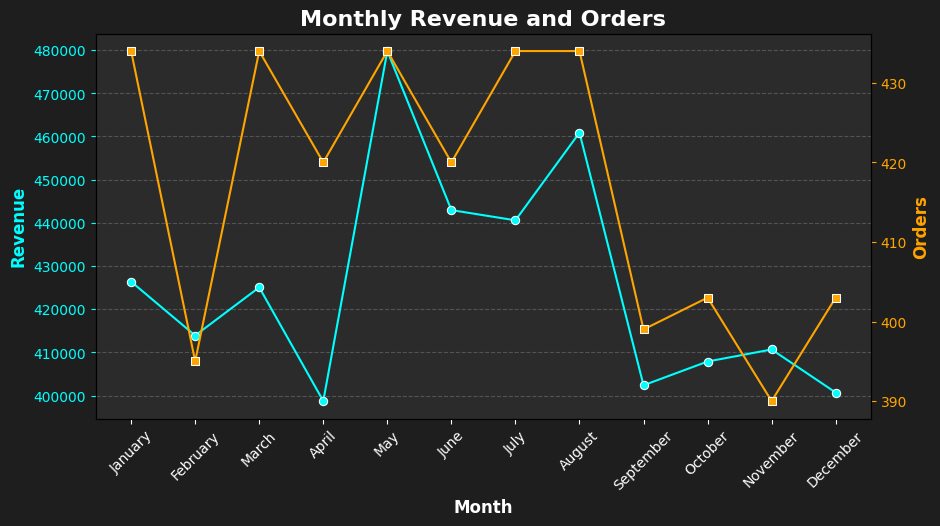

In [18]:
# 17. Dual Axis Plot: Monthly Revenue and Orders
# Question: How do monthly revenue and order counts compare over time?

monthly_rev = df.groupby("month")["revenue"].sum()
orders = df.groupby("month")["order_id"].count()

fig, ax1 = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#1e1e1e")
ax1.set_facecolor("#2b2b2b")

sns.lineplot(x=monthly_rev.index, y=monthly_rev.values, color="cyan", marker="o", ax=ax1)
ax2 = ax1.twinx()
sns.lineplot(x=orders.index, y=orders.values, color="orange", marker="s", ax=ax2)

plt.title("Monthly Revenue and Orders", color="white", fontsize=16, fontweight="bold")

ax1.set_xlabel("Month", color="white", fontsize=12, fontweight="bold")
ax1.set_ylabel("Revenue", color="cyan", fontsize=12, fontweight="bold")
ax2.set_ylabel("Orders", color="orange", fontsize=12, fontweight="bold")

ax1.tick_params(axis="x", colors="white", rotation=45)
ax1.tick_params(axis="y", colors="cyan")
ax2.tick_params(axis="y", colors="orange")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

plt.savefig("outputs/Monthly_Revenue_and_Orders.png", dpi=300, bbox_inches="tight")
plt.show()


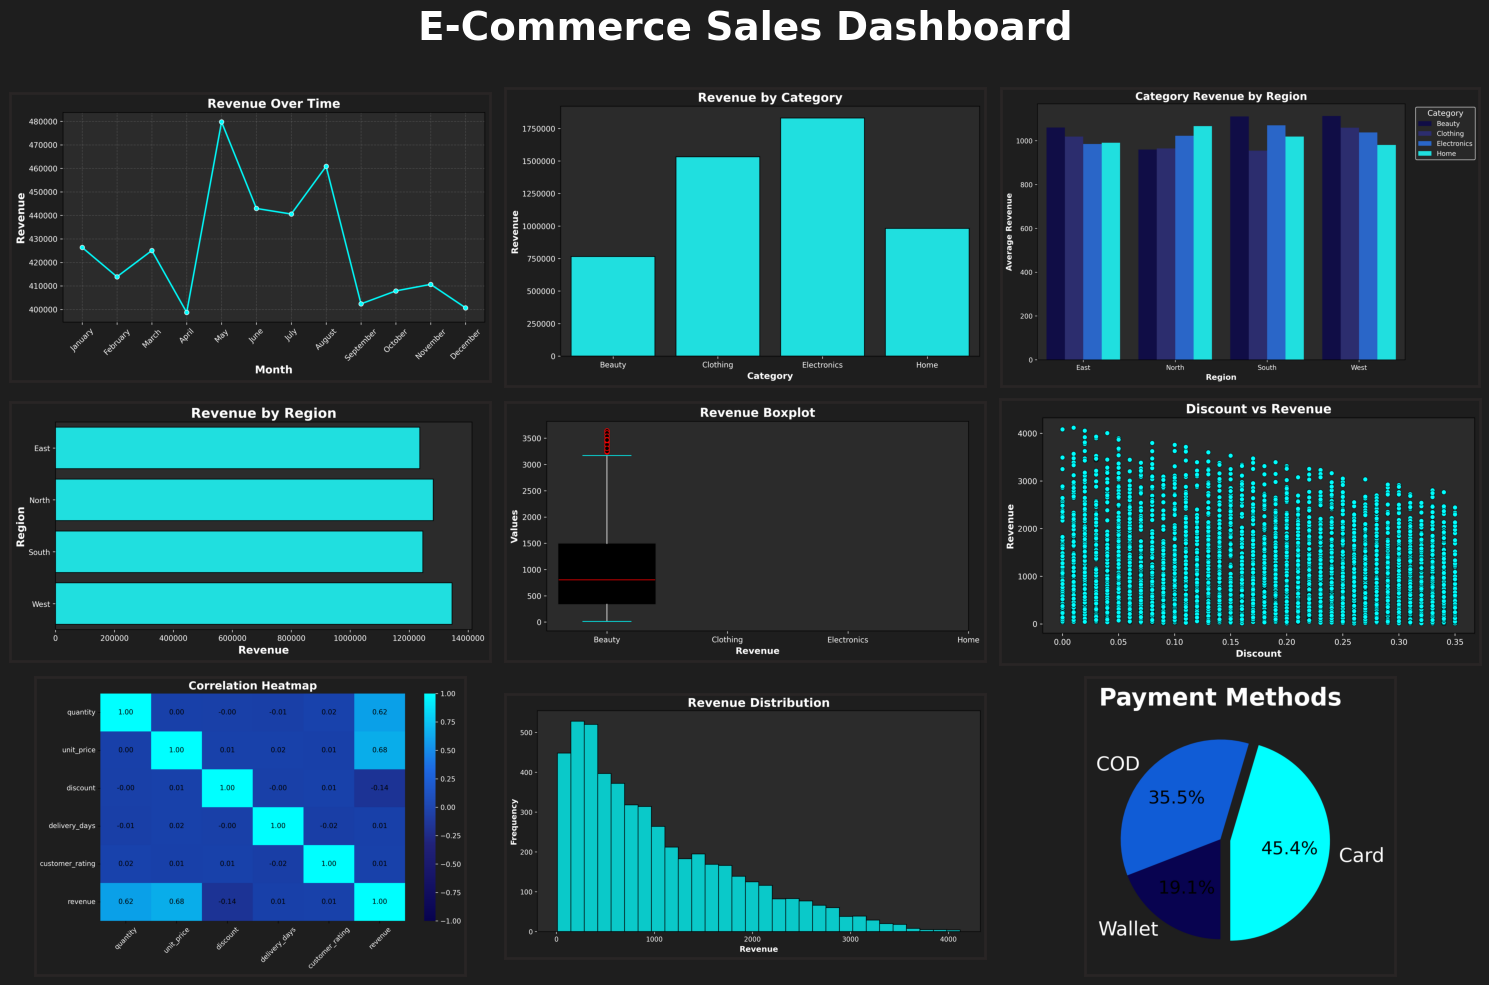

In [19]:
import matplotlib.pyplot as plt

images = [
    "outputs/Revenue_Over_Months.png",
    "outputs/Revenue_by_Product_Category.png",
    "outputs/Average_Revenue_by_Region_and_Category.png",
    
    "outputs/Revenue_by_Region.png",
    "outputs/Revenue_Boxplot.png",  
    "outputs/Discount_Vs_Revenue.png",
    "outputs/Correlation_Heatmap.png",
    "outputs/Revenue_Distribution.png",
    "outputs/Payment_Methods.png",
]


fig, axes = plt.subplots(3, 3, figsize=(15, 10))

fig.patch.set_facecolor("#1e1e1e")

for ax, img in zip(axes.ravel(), images):
    image = plt.imread(img)
    ax.imshow(image)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("#2b2b2b")
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#292525")
        spine.set_linewidth(2)

fig.suptitle("E-Commerce Sales Dashboard", fontsize=28, color="white", fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.savefig("outputs/E-Commerce_Sales_Dashboard.png", dpi=300, bbox_inches="tight")
plt.show()